#### R K T Dissanayake
#### 230164K

# IntensityTransformationsandNeighborhood Filtering

Importing necessary packages

In [2]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

### Implement the intensity transformation depicted in Fig.1 a on the image shown in Fig.1 b by writing a function intensity_transform(im,breakpoints)

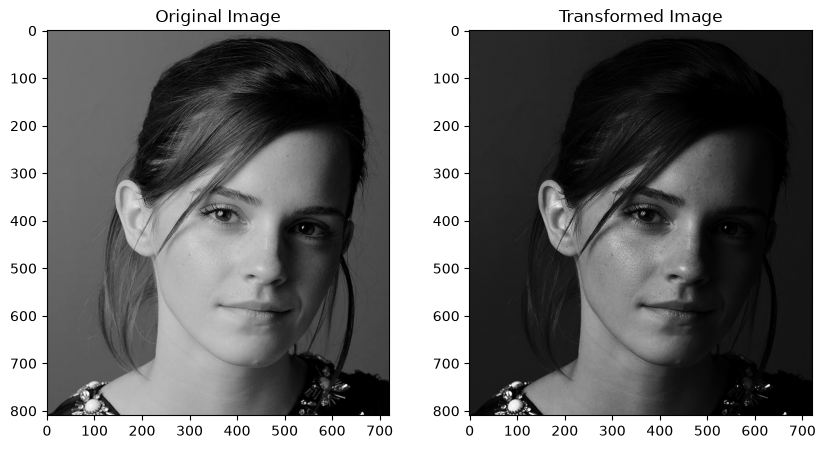

In [12]:
def intensity_transformation(im, breakpoints):
    for i in range(len(breakpoints) - 1):
        x1, y1 = breakpoints[i]
        x2, y2 = breakpoints[i + 1]
        slope = (y2 - y1) / (x2 - x1)
        intercept = y1 - slope * x1
        mask = (im >= x1) & (im < x2)
        im[mask] = (im[mask] * slope + intercept)%256

# Load an image
img = cv.imread(r"D:\Sem 5\IP and CV\images\images\emma.jpeg", cv.IMREAD_GRAYSCALE)

# breakpoints = [(0, 0), (80, 120), (150, 180), (230, 225), (255, 255)]
breakpoints = [(0,0), (100, 30), (150, 80), (200, 170), (220, 230),(255, 255)]
transformed_img = img.copy()
intensity_transformation(transformed_img, breakpoints)

# Display the image
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(img, cmap='gray')
plt.title('Original Image')
plt.subplot(1, 2, 2)
plt.imshow(transformed_img, cmap='gray')
plt.title('Transformed Image')
plt.show()

### Applying similar operation  to accentuate white matter

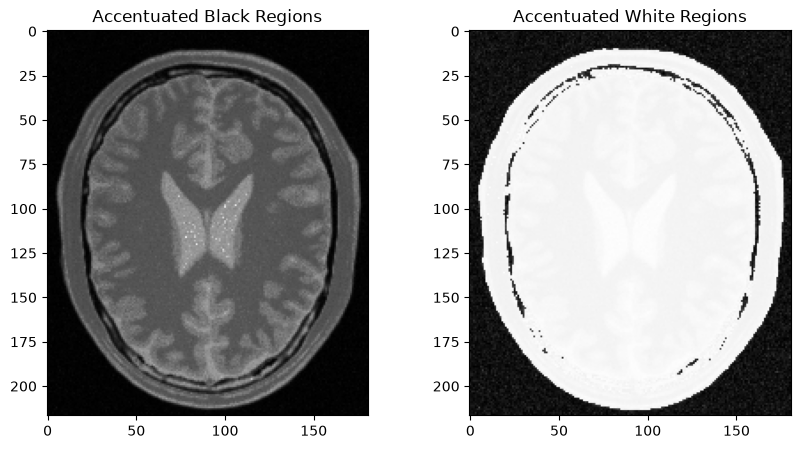

In [19]:
brain = cv.imread(r"D:\Sem 5\IP and CV\images\images\brain.png", cv.IMREAD_GRAYSCALE)

# define breakout points to accentuate white regions
white_breakpoints = [(0, 0), (80, 180), (140, 240), (255, 255)]
black_breakpoints = [(0, 0), (180, 80), (240, 140), (255, 255)]

white_transformed_img = brain.copy()
intensity_transformation(white_transformed_img, white_breakpoints)
black_transformed_img = brain.copy()
intensity_transformation(black_transformed_img, black_breakpoints)

# Display the image
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(black_transformed_img, cmap='gray')
plt.title('Accentuated Black Regions')
plt.subplot(1, 2, 2)
plt.imshow(white_transformed_img, cmap='gray')
plt.title('Accentuated White Regions')
plt.show()


## Gamma Correction

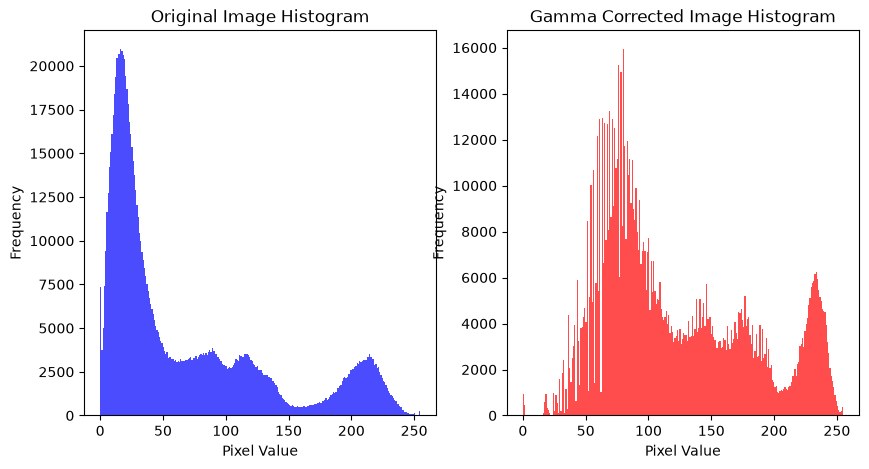

In [ ]:
# load image girl
girl = cv.imread(r"D:\Sem 5\IP and CV\images\images\girl.jpeg", cv.IMREAD_COLOR)

# convert to YUV color space
girl_yuv = cv.cvtColor(girl, cv.COLOR_BGR2YUV)

# applying gamma correction to L plane
girl_yuv[:,:,0] = np.power(girl_yuv[:,:,0]/255.0, 0.469) * 255.0

# convert back to BGR color space
girl_gamma_corrected = cv.cvtColor(girl_yuv, cv.COLOR_YUV2BGR)

# Display histogram of original and gamma corrected image
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.hist(girl.ravel(), bins=256, color='blue', alpha=0.7)
plt.title('Original Image Histogram')
plt.xlabel('Pixel Value')
plt.ylabel('Frequency')
plt.subplot(1, 2, 2)
plt.hist(girl_gamma_corrected.ravel(), bins=256, color='red', alpha=0.7)
plt.title('Gamma Corrected Image Histogram')
plt.xlabel('Pixel Value')
plt.ylabel('Frequency')
plt.show()


The gamma value is 0.469

### Increasing vibrance of a photo

In [33]:
def vibrance_intensity_transformation(input_intensity, vibrance_factor, sigma):
    value = (input_intensity + vibrance_factor * 128 * np.exp(-((input_intensity - 128) ** 2) / (2 * sigma ** 2)))%256
    return np.min(value, 255)

# load an image
peter = cv.imread(r"D:\Sem 5\IP and CV\images\images\peter.png", cv.IMREAD_COLOR)

# split image into hue, saturation, and value planes
peter_hsv = cv.cvtColor(peter, cv.COLOR_BGR2HSV)

# apply vibrance intensity transformation to saturation plane
a = 0.5  # vibrance factor
sigma = 70  # standard deviation for the Gaussian function
peter_hsv[:,:,1] = np.vectorize(vibrance_intensity_transformation)(peter_hsv[:,:,1], a, sigma)

# convert back to BGR color space
peter_vibrance_corrected = cv.cvtColor(peter_hsv, cv.COLOR_HSV2BGR)

# Display the image
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(cv.cvtColor(peter, cv.COLOR_BGR2RGB))
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(cv.cvtColor(peter_vibrance_corrected, cv.COLOR_BGR2RGB))
plt.title("Vibrance Corrected Image")
plt.axis("off")

plt.show()


C:\Users\USER\AppData\Local\Temp\ipykernel_3240\855878233.py:2: RuntimeWarning: overflow encountered in scalar subtract
  value = (input_intensity + vibrance_factor * 128 * np.exp(-((input_intensity - 128) ** 2) / (2 * sigma ** 2)))%256
C:\Users\USER\AppData\Local\Temp\ipykernel_3240\855878233.py:2: RuntimeWarning: overflow encountered in scalar negative
  value = (input_intensity + vibrance_factor * 128 * np.exp(-((input_intensity - 128) ** 2) / (2 * sigma ** 2)))%256


AxisError: axis 255 is out of bounds for array of dimension 0